In [28]:
import os
import random
import re

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import seaborn as sns
from dotenv import load_dotenv
from transformers import AutoTokenizer
from wordcloud import WordCloud, STOPWORDS

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
font_prop = fm.FontProperties(fname=font_path)

plt.rc("font", family=font_prop.get_name())
fm.fontManager.addfont(font_path)
plt.rcParams["axes.unicode_minus"] = False

load_dotenv()
OS_PATH = os.getenv("OS_PATH")
DATA_PATH = os.path.join(OS_PATH, "data")

train_df = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
val_df = pd.read_csv(os.path.join(DATA_PATH, "dev.csv"))
test_df = pd.read_csv(os.path.join(DATA_PATH, "test.csv"))

#### 1. 인덱스 결측치 확인

In [29]:
def check_missing_ids(file_path, prefix):
    df = pd.read_csv(file_path)
    df["idx_num"] = df["fname"].str.replace(f"{prefix}_", "").astype(int)

    full_range = set(range(df["idx_num"].min(), df["idx_num"].max() + 1))
    actual_range = set(df["idx_num"])
    missing_ids = sorted(list(full_range - actual_range))

    print(f"--- {file_path} 분석 결과 ---")
    print(f"총 데이터: {len(df)}건")
    print(f"인덱스 번호: {df['idx_num'].min()} ~ {df['idx_num'].max()}")
    print(f"누락 건수: {len(missing_ids)}건")
    if missing_ids:
        print(f"누락 인덱스: {missing_ids}\n")

check_missing_ids(os.path.join(DATA_PATH, "train.csv"), "train")             # 학습데이터
check_missing_ids(os.path.join(DATA_PATH, "dev.csv"), "dev")                 # 검증데이터
check_missing_ids(os.path.join(DATA_PATH, "test.csv"), "test")               # 평가데이터
check_missing_ids(os.path.join(DATA_PATH, "sample_submission.csv"), "test")  # 제출데이터

duplicates = train_df[train_df.duplicated(subset=["dialogue"], keep=False)]
print(f"중복된 대화 수: {len(duplicates)}건\n")

--- /data/ephemeral/home/nlp-dialogue-summarization/data/train.csv 분석 결과 ---
총 데이터: 12457건
인덱스 번호: 0 ~ 12459
누락 건수: 3건
누락 인덱스: [10933, 10972, 11473]

--- /data/ephemeral/home/nlp-dialogue-summarization/data/dev.csv 분석 결과 ---
총 데이터: 499건
인덱스 번호: 0 ~ 499
누락 건수: 1건
누락 인덱스: [475]

--- /data/ephemeral/home/nlp-dialogue-summarization/data/test.csv 분석 결과 ---
총 데이터: 499건
인덱스 번호: 0 ~ 499
누락 건수: 1건
누락 인덱스: [466]

--- /data/ephemeral/home/nlp-dialogue-summarization/data/sample_submission.csv 분석 결과 ---
총 데이터: 499건
인덱스 번호: 0 ~ 499
누락 건수: 1건
누락 인덱스: [466]

중복된 대화 수: 0건



#### 2. 대화문 & 요약문 (토큰)

In [30]:
# 토큰 계산 함수
model_name = "digit82/kobart-summarization"
tokenizer = AutoTokenizer.from_pretrained(model_name)

special_tokens = [
    "#Person1#", "#Person2#", "#Person3#", "#Person4#", "#Person5#", "#Person6#", "#Person7#",
    "#PhoneNumber#", "#Address#", "#DateOfBirth#", "#PassportNumber#", "#SSN#",
    "#CardNumber#", "#CarNumber#", "#Email#"
]
tokenizer.add_special_tokens({"additional_special_tokens": special_tokens})

def get_token_len(text):
    if not isinstance(text, str): return 0
    return len(tokenizer.encode(text, add_special_tokens=True))

In [31]:
# 대화문 토큰 길이 분포
train_df["dialogue_token_len"] = train_df["dialogue"].apply(get_token_len)
val_df["dialogue_token_len"] = val_df["dialogue"].apply(get_token_len)
test_df["dialogue_token_len"] = test_df["dialogue"].apply(get_token_len)

print("--- 대화문 토큰 길이 (학습) ---")
print(train_df["dialogue_token_len"].describe(), "\n")
print("--- 대화문 토큰 길이 (검증) ---")
print(val_df["dialogue_token_len"].describe(), "\n")
print("--- 대화문 토큰 길이 (평가) ---")
print(test_df["dialogue_token_len"].describe(), "\n")

--- 대화문 토큰 길이 (학습) ---
count    12457.000000
mean       151.917075
std         76.537587
min         32.000000
25%        102.000000
50%        136.000000
75%        189.000000
max        918.000000
Name: dialogue_token_len, dtype: float64 

--- 대화문 토큰 길이 (검증) ---
count    499.000000
mean     149.434870
std       72.293309
min       39.000000
25%       99.500000
50%      134.000000
75%      186.000000
max      525.000000
Name: dialogue_token_len, dtype: float64 

--- 대화문 토큰 길이 (평가) ---
count    499.000000
mean     158.865731
std       85.385401
min       40.000000
25%      102.000000
50%      146.000000
75%      201.500000
max      930.000000
Name: dialogue_token_len, dtype: float64 



In [32]:
# 요약문 토큰 길이 분포
train_df["summary_token_len"] = train_df["summary"].apply(get_token_len)
val_df["summary_token_len"] = val_df["summary"].apply(get_token_len)

print("--- 요약문 토큰 길이 (학습) ---")
print(train_df["summary_token_len"].describe(), "\n")
print("--- 요약문 토큰 길이 (검증) ---")
print(val_df["summary_token_len"].describe(), "\n")

--- 요약문 토큰 길이 (학습) ---
count    12457.000000
mean        31.217067
std         12.957006
min          6.000000
25%         22.000000
50%         29.000000
75%         38.000000
max        156.000000
Name: summary_token_len, dtype: float64 

--- 요약문 토큰 길이 (검증) ---
count    499.000000
mean      29.416834
std       12.640797
min       10.000000
25%       21.000000
50%       27.000000
75%       36.000000
max       98.000000
Name: summary_token_len, dtype: float64 



In [33]:
q_train = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0]
t_train = train_df["dialogue_token_len"].quantile(q_train).tolist()

print("\n--- 구간 대화문 토큰 경계값 (학습) ---")
for q, val in zip(q_train, t_train):
    print(f"상위 {q*100:>3.0f}% 지점: {val:.1f}")

q_val = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0]
t_val = val_df["dialogue_token_len"].quantile(q_val).tolist()

print("\n--- 구간 대화문 토큰 경계값 (검증) ---")
for q, val in zip(q_val, t_val):
    print(f"상위 {q*100:>3.0f}% 지점: {val:.1f}")

q_test = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0]
t_test = test_df["dialogue_token_len"].quantile(q_test).tolist()

print("\n--- 구간 대화문 토큰 경계값 (평가) ---")
for q, val in zip(q_test, t_test):
    print(f"상위 {q*100:>3.0f}% 지점: {val:.1f}")


--- 구간 대화문 토큰 경계값 (학습) ---
상위  10% 지점: 70.0
상위  20% 지점: 94.0
상위  30% 지점: 109.0
상위  40% 지점: 122.0
상위  50% 지점: 136.0
상위  60% 지점: 154.0
상위  70% 지점: 176.0
상위  80% 지점: 203.0
상위  90% 지점: 244.0
상위  95% 지점: 284.0
상위 100% 지점: 918.0

--- 구간 대화문 토큰 경계값 (검증) ---
상위  10% 지점: 69.0
상위  20% 지점: 93.0
상위  30% 지점: 107.0
상위  40% 지점: 117.2
상위  50% 지점: 134.0
상위  60% 지점: 151.0
상위  70% 지점: 173.0
상위  80% 지점: 200.8
상위  90% 지점: 244.6
상위  95% 지점: 287.0
상위 100% 지점: 525.0

--- 구간 대화문 토큰 경계값 (평가) ---
상위  10% 지점: 70.0
상위  20% 지점: 91.0
상위  30% 지점: 110.0
상위  40% 지점: 125.0
상위  50% 지점: 146.0
상위  60% 지점: 160.8
상위  70% 지점: 185.0
상위  80% 지점: 219.0
상위  90% 지점: 255.0
상위  95% 지점: 295.1
상위 100% 지점: 930.0


In [34]:
q_train = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0]
t_train = train_df["summary_token_len"].quantile(q_train).tolist()

print("\n--- 구간 요약문 토큰 경계값 (학습) ---")
for q, val in zip(q_train, t_train):
    print(f"상위 {q*100:>3.0f}% 지점: {val:.1f}")

q_val = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0]
t_val = val_df["summary_token_len"].quantile(q_val).tolist()

print("\n--- 구간 요약문 토큰 경계값 (검증) ---")
for q, val in zip(q_val, t_val):
    print(f"상위 {q*100:>3.0f}% 지점: {val:.1f}")


--- 구간 요약문 토큰 경계값 (학습) ---
상위  10% 지점: 17.0
상위  20% 지점: 20.0
상위  30% 지점: 23.0
상위  40% 지점: 26.0
상위  50% 지점: 29.0
상위  60% 지점: 32.0
상위  70% 지점: 36.0
상위  80% 지점: 40.0
상위  90% 지점: 48.0
상위  95% 지점: 55.0
상위 100% 지점: 156.0

--- 구간 요약문 토큰 경계값 (검증) ---
상위  10% 지점: 16.0
상위  20% 지점: 19.0
상위  30% 지점: 22.0
상위  40% 지점: 24.0
상위  50% 지점: 27.0
상위  60% 지점: 30.0
상위  70% 지점: 34.0
상위  80% 지점: 37.0
상위  90% 지점: 46.0
상위  95% 지점: 52.0
상위 100% 지점: 98.0



[분석 결과] 대화문-요약문 길이 상관계수 (학습): 0.7481

[구간별 요약문 통계 (학습)]
             mean        std  min  max  count   75%
group                                              
Short   22.031587   6.736187    6   60   4179  26.0
Middle  29.481867   8.175296   10   85   4136  34.0
Long    42.217286  13.538130   11  156   4142  49.0


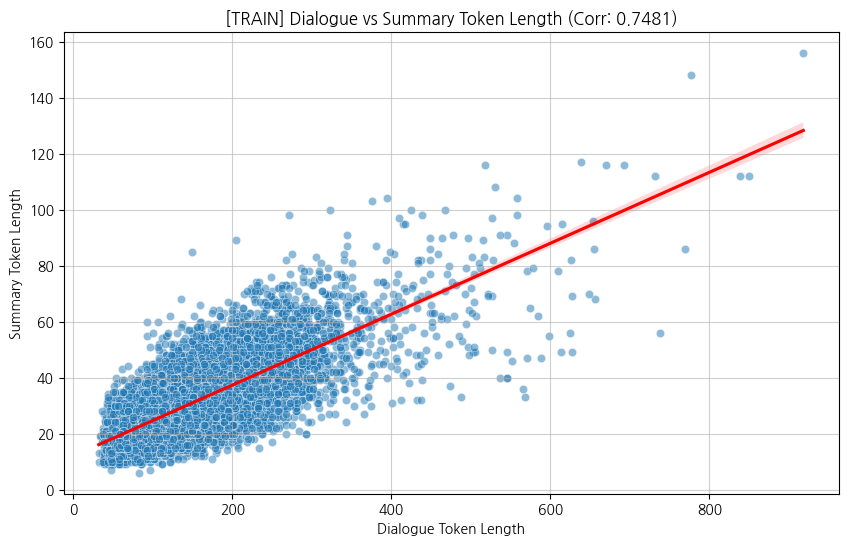

In [35]:
# 상관계수 (학습)
correlation = train_df["dialogue_token_len"].corr(train_df["summary_token_len"])
print(f"\n[분석 결과] 대화문-요약문 길이 상관계수 (학습): {correlation:.4f}")

# dialogue_len 기준 33%, 66% 지점으로 분할
train_df["group"] = pd.qcut(train_df["dialogue_token_len"], 3, labels=["Short", "Middle", "Long"])
group_stats = train_df.groupby("group", observed=False)["summary_token_len"].agg(["mean", "std", "min", "max", "count", lambda x: x.quantile(0.75)])
group_stats.columns = ["mean", "std", "min", "max", "count", "75%"]

print("\n[구간별 요약문 통계 (학습)]")
print(group_stats)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=train_df, x="dialogue_token_len", y="summary_token_len", alpha=0.5)
sns.regplot(data=train_df, x="dialogue_token_len", y="summary_token_len", scatter=False, color="red")
plt.title(f"[TRAIN] Dialogue vs Summary Token Length (Corr: {correlation:.4f})")
plt.xlabel("Dialogue Token Length")
plt.ylabel("Summary Token Length")
plt.grid(True, alpha=0.6)
plt.show()


[분석 결과] 대화문-요약문 길이 상관계수 (검증): 0.7362

[구간별 요약문 통계 (검증)]
             mean        std  min  max  count   75%
group                                              
Short   21.204819   6.574070   10   50    166  24.0
Middle  27.491018   7.631473   14   51    167  33.0
Long    39.566265  14.325813   13   98    166  47.0


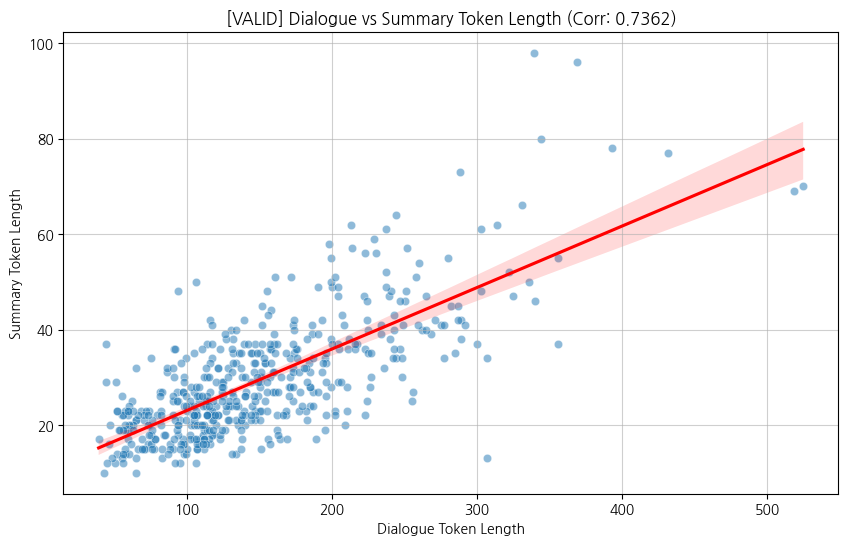

In [36]:
# 상관계수 (검증)
correlation = val_df["dialogue_token_len"].corr(val_df["summary_token_len"])
print(f"\n[분석 결과] 대화문-요약문 길이 상관계수 (검증): {correlation:.4f}")

# dialogue_len 기준 33%, 66% 지점으로 분할
val_df["group"] = pd.qcut(val_df["dialogue_token_len"], 3, labels=["Short", "Middle", "Long"])
group_stats = val_df.groupby("group", observed=False)["summary_token_len"].agg(["mean", "std", "min", "max", "count", lambda x: x.quantile(0.75)])
group_stats.columns = ["mean", "std", "min", "max", "count", "75%"]

print("\n[구간별 요약문 통계 (검증)]")
print(group_stats)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=val_df, x="dialogue_token_len", y="summary_token_len", alpha=0.5)
sns.regplot(data=val_df, x="dialogue_token_len", y="summary_token_len", scatter=False, color="red")
plt.title(f"[VALID] Dialogue vs Summary Token Length (Corr: {correlation:.4f})")
plt.xlabel("Dialogue Token Length")
plt.ylabel("Summary Token Length")
plt.grid(True, alpha=0.6)
plt.show()

In [37]:
# 대화 길이 분포 (Solar API용)
train_df["dialogue_len"] = train_df["dialogue"].apply(len)
print("--- 대화문 길이 (학습) ---")
print(train_df["dialogue_len"].describe(), "\n")

val_df["dialogue_len"] = val_df["dialogue"].apply(len)
print("--- 대화문 길이 (검증) ---")
print(val_df["dialogue_len"].describe(), "\n")

test_df["dialogue_len"] = test_df["dialogue"].apply(len)
print("--- 대화문 길이 (평가) ---")
print(test_df["dialogue_len"].describe(), "\n")

train_df["summary_len"] = train_df["summary"].apply(len)
print("--- 요약문 길이 (학습) ---")
print(train_df["summary_len"].describe(), "\n")

val_df["summary_len"] = val_df["summary"].apply(len)
print("--- 요약문 길이 (검증) ---")
print(val_df["summary_len"].describe(), "\n")

--- 대화문 길이 (학습) ---
count    12457.000000
mean       406.083487
std        197.566083
min         84.000000
25%        280.000000
50%        369.000000
75%        500.000000
max       2165.000000
Name: dialogue_len, dtype: float64 

--- 대화문 길이 (검증) ---
count     499.000000
mean      400.054108
std       186.163807
min       114.000000
25%       273.000000
50%       367.000000
75%       487.000000
max      1269.000000
Name: dialogue_len, dtype: float64 

--- 대화문 길이 (평가) ---
count     499.000000
mean      422.066132
std       218.245122
min       111.000000
25%       280.000000
50%       386.000000
75%       528.500000
max      2275.000000
Name: dialogue_len, dtype: float64 

--- 요약문 길이 (학습) ---
count    12457.000000
mean        85.789436
std         33.811948
min         13.000000
25%         61.000000
50%         80.000000
75%        104.000000
max        376.000000
Name: summary_len, dtype: float64 

--- 요약문 길이 (검증) ---
count    499.000000
mean      81.206413
std       32.577548
min  

--- 호칭 예외 처리 후 요약문 문장 수 통계 ---
count    12457.000000
mean         1.619090
std          0.731855
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          8.000000
Name: sentence_count, dtype: float64

요약문 최빈값: 1개


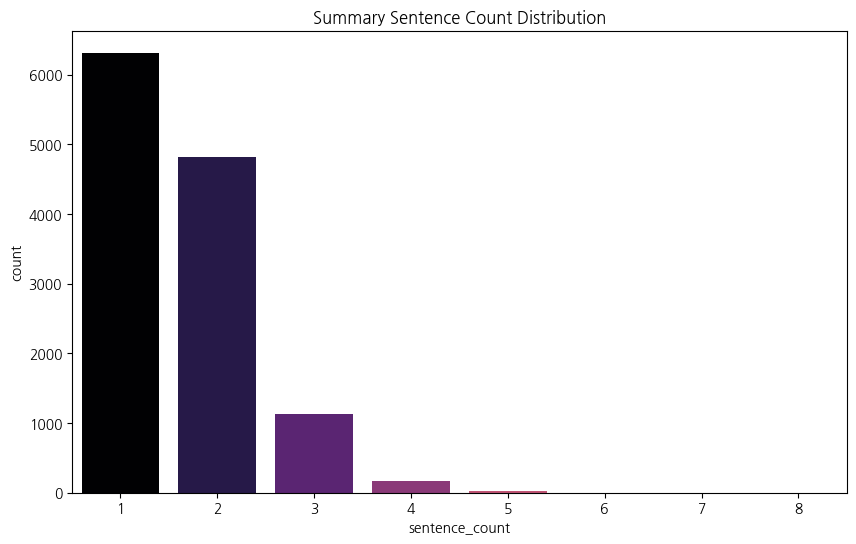

In [38]:
# 요약문 문장 수
def count_sentences(text):
    if not isinstance(text, str):
        return 0

    # 뒤에 마침표가 붙어도 문장 끝이 아닌 단어들
    titles = r"(Mr|Mrs|Ms|Dr|St|Gen|Col|Prof|Jr|Sr)\."

    # 호칭 뒤의 마침표를 특수 기호([DOT])로 임시 변환
    temp_text = re.sub(titles, lambda m: m.group(1) + "[DOT]", text, flags=re.IGNORECASE)

    # 실제 문장 구분자로 분리 (. ! ? 를 기준으로 하며 뒤에 공백이 오는 경우)
    sentences = re.split(r"[.!?](\s+|$)", temp_text.strip())
    actual_sentences = [s for s in sentences if s and len(s.strip()) > 1]

    return len(actual_sentences)

def analyze_summary(df):
    df["sentence_count"] = df["summary"].apply(count_sentences)

    print("--- 호칭 예외 처리 후 요약문 문장 수 통계 ---")
    print(df["sentence_count"].describe())

    # 최빈값 확인
    mode_val = df["sentence_count"].mode()[0]
    print(f"\n요약문 최빈값: {mode_val}개")

    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x="sentence_count", hue="sentence_count", palette="magma", legend=False)
    plt.title("Summary Sentence Count Distribution")
    plt.show()

analyze_summary(train_df)

#### 3. Turn

In [39]:
# 줄바꿈 없는 턴 수정
def fix_dialogue(text):
    fixed = re.sub(r"(?<!^)(#Person[1-7]#:)", r"\n\1", text)
    fixed = re.sub(r"\n+", r"\n", fixed).strip()
    return fixed

train_df["dialogue_fixed"] = train_df["dialogue"].apply(fix_dialogue)
train_df["turn_count_fixed"] = train_df["dialogue_fixed"].apply(lambda x: len(x.split("\n")))

check_ids = [7800, 6535, 6869, 129, 8375]
print(train_df.loc[train_df.index.isin(check_ids), ["dialogue_fixed", "turn_count_fixed"]])

sample_id = 6869
original_text = train_df.loc[sample_id, "dialogue"]
fixed_text = fix_dialogue(original_text)

print(f"\n--- [ID: {sample_id}] 수정 후 대화 내용 ---")
print(fixed_text)

                                         dialogue_fixed  turn_count_fixed
129   #Person1#: 저, 불만이 있어요. 열 분 동안 테이블에서 기다렸는데, 웨이터...                 2
6535  #Person1#: 안녕하세요, Joanna. 새 드레스 정말 매력적이에요. \n#...                 7
6869  #Person1#: 여보세요, 국제학생 오피스입니다. Leah입니다. 어떻게 도와드...                20
7800  #Person1#: 필름 현상 맡기려고요. \n#Person2#: 컬러 사진인가요?...                 6
8375  #Person1#: 할아버지, 이 식당 정말 오래돼 보이네요! 언제 지어진 건가요?...                14

--- [ID: 6869] 수정 후 대화 내용 ---
#Person1#: 여보세요, 국제학생 오피스입니다. Leah입니다. 어떻게 도와드릴까요? 
#Person2#: Collins 씨와 통화하고 싶습니다. 
#Person1#: 알겠습니다. 실례지만, 누구신가요? 
#Person2#: 저는 Nathaniel Brown입니다. 
#Person1#: 어떤 일로 전화하셨나요? 
#Person2#: 제 숙소 문제에 대해 이야기하고 싶습니다. 
#Person1#: 알겠습니다. 연결해 드릴게요. 잠시만 기다려 주세요. 
#Person2#: 네. 
#Person1#: ... 죄송합니다, 지금 그녀의 라인이 바쁩니다. 메시지를 남겨 드릴까요? 
#Person2#: 네, 제 휴대폰 번호로 연락 주시길 부탁드립니다. 
#Person1#: 알겠습니다. 번호가 어떻게 되나요? 
#Person2#: #PhoneNumber#입니다. 
#Person1#: 제가 다시 확인할게요. #PhoneNumber# 맞나요? 
#Person2#: 아니요, 번호 끝에 66은 없습니다. 그냥 #PhoneNumber#입니다. 

[턴 수 극단값 비교 분석]
   Metric  High-Turn (Long)  Low-Turn (Short)
 평균 대화 토큰        258.069133         81.468851
 평균 요약 토큰         43.724075         23.087540
턴당 토큰(밀도)         15.172360         21.056113
     샘플 수       1649.000000       1862.000000


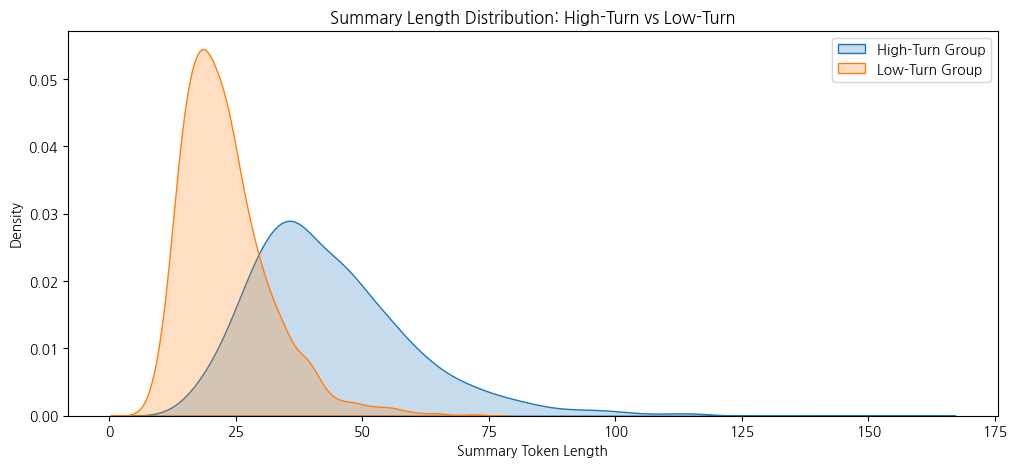

In [40]:
# 턴 수 기준으로 상위 10%, 하위 10% 경계값 계산
top_10_threshold = train_df["turn_count_fixed"].quantile(0.9)
bottom_10_threshold = train_df["turn_count_fixed"].quantile(0.1)

high_turn_df = train_df[train_df["turn_count_fixed"] >= top_10_threshold].copy()
low_turn_df = train_df[train_df["turn_count_fixed"] <= bottom_10_threshold].copy()

# 주요 지표 비교 통계량
comparison = pd.DataFrame({
    "Metric": ["평균 대화 토큰", "평균 요약 토큰", "턴당 토큰(밀도)", "샘플 수"],
    "High-Turn (Long)": [
        high_turn_df["dialogue_token_len"].mean(),
        high_turn_df["summary_token_len"].mean(),
        (high_turn_df["dialogue_token_len"] / high_turn_df["turn_count_fixed"]).mean(),
        len(high_turn_df)
    ],
    "Low-Turn (Short)": [
        low_turn_df["dialogue_token_len"].mean(),
        low_turn_df["summary_token_len"].mean(),
        (low_turn_df["dialogue_token_len"] / low_turn_df["turn_count_fixed"]).mean(),
        len(low_turn_df)
    ]
})

print("[턴 수 극단값 비교 분석]")
print(comparison.to_string(index=False))

plt.figure(figsize=(12, 5))
sns.kdeplot(high_turn_df["summary_token_len"], label="High-Turn Group", fill=True)
sns.kdeplot(low_turn_df["summary_token_len"], label="Low-Turn Group", fill=True)
plt.title("Summary Length Distribution: High-Turn vs Low-Turn")
plt.xlabel("Summary Token Length")
plt.legend()
plt.show()

In [41]:
# 턴은 긴데 요약은 짧은 대화
weird_samples = high_turn_df.sort_values(by="summary_token_len").head(3)
for i, row in weird_samples.iterrows():
    print(f"[턴 수: {row['turn_count_fixed']}, 요약 길이: {row['summary_token_len']}]")
    print(f"대화 내용 요약: {row['summary']}", "\n")

[턴 수: 14, 요약 길이: 14]
대화 내용 요약: Linda는 #Person1#와 중국에서의 첫 식사 경험을 이야기한다. 

[턴 수: 17, 요약 길이: 14]
대화 내용 요약: #Person2#가 #Person1#의 도움으로 뉴욕 왕복 항공권을 구매합니다. 

[턴 수: 16, 요약 길이: 14]
대화 내용 요약: #Person2#는 직장을 찾고 있으며 #Person1#에게 기본 정보를 제공합니다. 



In [42]:
# 턴 수 기준 정렬 (내림차순)
sorted_df = train_df.sort_values(by="turn_count_fixed", ascending=False)

# 최대 턴수 데이터 (top 5)
max_turns_samples = sorted_df.head(5)
# 최소 턴수 데이터 (bottom 5)
min_turns_samples = sorted_df.tail(5)

print(f"전체 데이터 중 최대 턴수: {train_df['turn_count_fixed'].max()}")
print(f"전체 데이터 중 최소 턴수: {train_df['turn_count_fixed'].min()}")

def print_samples(df, title):
    print(f"\n{'='*30} {title} {'='*30}")
    for i, row in df.iterrows():
        print(f"\n[ID: {i} | 턴수: {row['turn_count_fixed']} | 대화토큰: {row['dialogue_token_len']} | 요약토큰: {row['summary_token_len']}]")
        print(f"요약문: {row['summary']}")
        print("-" * 20)
        print(f"대화문(일부): {row['dialogue'][:200]}...")

print_samples(max_turns_samples, "최대 턴수 샘플 (알맹이 확인용)")
print_samples(min_turns_samples, "최소 턴수 샘플 (정보 밀도 확인용)")

전체 데이터 중 최대 턴수: 59
전체 데이터 중 최소 턴수: 2

============================== 최대 턴수 샘플 (알맹이 확인용) ==============================

[ID: 3210 | 턴수: 59 | 대화토큰: 769 | 요약토큰: 86]
요약문: Stacy는 새로 이사 온 Mark Jones를 동네에 환영합니다. Mark는 이삿짐 업체의 도움으로 이사를 했고, 고양이가 사라진 것 외에는 순조로웠습니다. 그는 교육 소프트웨어를 개발하는 소프트웨어 개발자이고, Stacy는 고등학교 역사 교사입니다. Stacy는 금요일에 있을 바베큐 파티에 Mark 가족을 초대하고, 고양이를 짐 상자에서 발견합니다.
--------------------
대화문(일부): #Person1#: 안녕하세요. 
#Person2#: 아, 안녕하세요. 
#Person1#: 동네에 새로 오신 거예요? 
#Person2#: 아, 네. 
#Person1#: 우리 동네에 온 걸 환영해요. 
#Person2#: 아. 
#Person1#: 저는 Stacy예요. 길 건너 사는데요. 
#Person2#: 아, 안녕하세요, Stacy. 저는 Mark...

[ID: 5259 | 턴수: 48 | 대화토큰: 627 | 요약토큰: 49]
요약문: #Person1#은 주말 여행을 위해 #Person2#에게 강아지 Jaws, 고양이 Claws, 뱀 Buttercup을 돌봐줄 것을 부탁합니다. 하지만 #Person2#는 까다로운 관리 조건 때문에 이를 거절합니다.
--------------------
대화문(일부): #Person1#: 안녕하세요, 이웃님. 잘 지내시죠?
#Person2#: 네, 잘 지내요. 당신은요?
#Person1#: 저도 괜찮아요. 다름이 아니라, 이번 주말에 저랑 아내가 여행을 가는데 강아지 좀 돌봐주실 수 있을까요? 우리 강아지 Jaws 아시죠?
#Person2#: 네, 근데 Jaws 때문에 아직 다리가 아파요.
#Person1#: 아, 걔가

[분석 결과] 턴-대화문 토큰 길이 상관계수 (학습): 0.7434


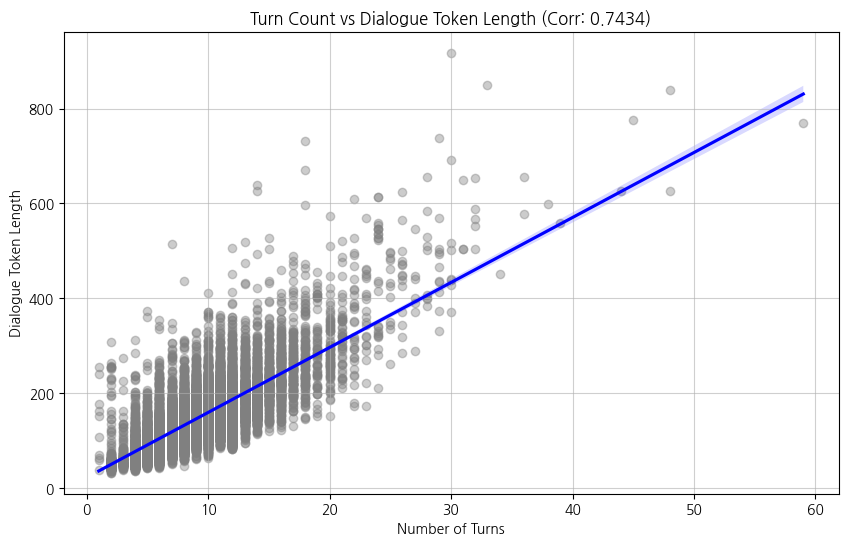

턴당 평균 토큰 수: 16.87


In [43]:
# 턴 수 vs 대화문 토큰 길이 상관계수
train_df["turn_count_fixed"] = train_df["dialogue"].apply(lambda x: len([line for line in x.strip().split("\n") if line.strip()]))
dist_correlation = train_df["turn_count_fixed"].corr(train_df["dialogue_token_len"])
print(f"[분석 결과] 턴-대화문 토큰 길이 상관계수 (학습): {dist_correlation:.4f}")

plt.figure(figsize=(10, 6))
sns.regplot(data=train_df, x="turn_count_fixed", y="dialogue_token_len", scatter_kws={"alpha":0.4, "color":"gray"}, line_kws={"color":"blue"})
plt.title(f"Turn Count vs Dialogue Token Length (Corr: {dist_correlation:.4f})")
plt.xlabel("Number of Turns")
plt.ylabel("Dialogue Token Length")
plt.grid(True, alpha=0.6)
plt.show()

train_df["tokens_per_turn"] = train_df["dialogue_token_len"] / train_df["turn_count_fixed"]
print(f"턴당 평균 토큰 수: {train_df['tokens_per_turn'].mean():.2f}")

최대 참여 인원: 7명
평균 참여 인원: 2.01명
줄바꿈 누락: 10건
화자 태그 포맷 위반: 0건


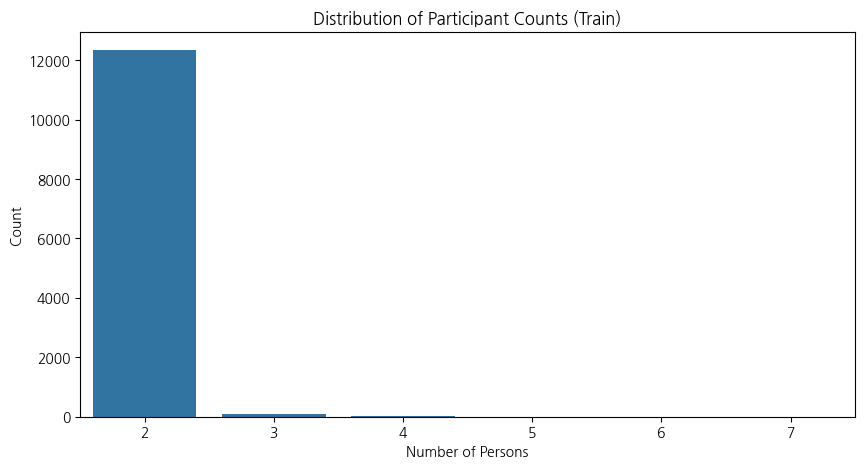

In [44]:
def check_dialogue(df, stage="Train"):
    # 각 대화당 등장하는 인원수 추출
    def count_participants(text):
        participants = re.findall(r"#Person(\d+)#:", text)
        return len(set(participants))

    df["person_count"] = df["dialogue"].apply(count_participants)

    # 줄바꿈(\n) 규칙 준수 여부 확인
    df["has_newline"] = df["dialogue"].str.contains("\n")
    newline_violation = df[df["has_newline"] == False]

    # 화자 태그 포맷 위반 확인
    def check_format_violation(text):
        # 콜론이 빠진 패턴 (#Person1# ) 등 검사
        # bad_patterns = re.findall(r"#Person\d+#(?!\:)", text) # 문장 중간에 등장하는 경우 있음!
        bad_patterns = re.findall(r"(^|\n)(#Person\d#)(?!\:)", text)
        return len(bad_patterns) > 0

    df["format_error"] = df["dialogue"].apply(check_format_violation)

    print(f"최대 참여 인원: {df['person_count'].max()}명")
    print(f"평균 참여 인원: {df['person_count'].mean():.2f}명")
    print(f"줄바꿈 누락: {len(newline_violation)}건")
    print(f"화자 태그 포맷 위반: {df['format_error'].sum()}건")

    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x="person_count")
    plt.title(f"Distribution of Participant Counts ({stage})")
    plt.xlabel("Number of Persons")
    plt.ylabel("Count")
    plt.show()

check_dialogue(train_df, "Train")

#### 3. Topic

In [45]:
# topic별 데이터 비중 시각화
fig = px.treemap(train_df, path=["topic"], title="Topic Distribution")
fig.write_html(os.path.join(OS_PATH, "assets/treemap.html"))

In [46]:
train_df["topic"] = train_df["topic"].str.strip()
topic_counts = train_df["topic"].value_counts()
print(f"공백 정제 후 topic 종류: {len(topic_counts)}개\n")
print(topic_counts)

공백 정제 후 topic 종류: 9235개

topic
음식 주문        130
취업 면접        109
길 안내          66
호텔 체크인        40
아파트 임대        30
            ... 
애정             1
독서 토론          1
술자리            1
결혼과 관계 종료      1
실직과 대처         1
Name: count, Length: 9235, dtype: int64


In [47]:
# topic 빈도별 분포 (건수별 그룹화)
print("출현횟수 | 건수")
count_distribution = topic_counts.value_counts().sort_index()
count_distribution

출현횟수 | 건수


count
1      8041
2       686
3       215
4        92
5        63
6        37
7        22
8        14
9        10
10        7
11        6
12        6
13        4
14        7
15        5
16        2
18        1
20        2
21        3
22        1
23        1
25        2
26        1
27        1
29        1
30        1
40        1
66        1
109       1
130       1
Name: count, dtype: int64

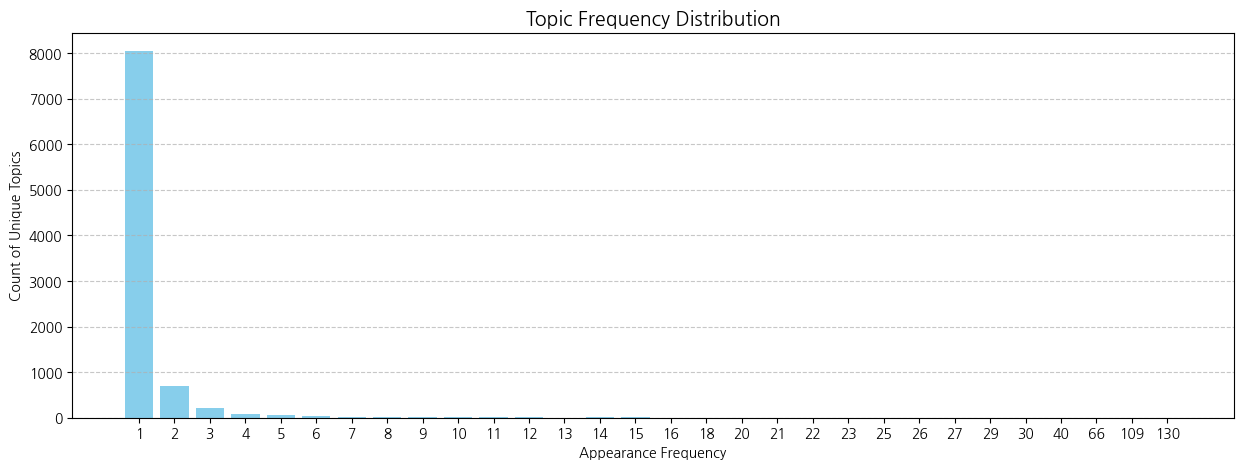

In [48]:
# topic 빈도별 분포 시각화 (Long-tail Check)
plt.figure(figsize=(15, 5))
plt.bar(count_distribution.index.astype(str), count_distribution.values, color="skyblue")
plt.title("Topic Frequency Distribution", fontsize=14)
plt.xlabel("Appearance Frequency")
plt.ylabel("Count of Unique Topics")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [49]:
# 1회성 topic 분석
df_ana = topic_counts.reset_index()
df_ana.columns = ["topic_name", "frequency"]

fq = df_ana[df_ana["frequency"] == 1]
total_count = len(train_df)
single_count = len(fq)

print(f"전체 데이터 수: {total_count}개")
print(f"1회성 토픽 비중: {(single_count / total_count) * 100:.2f}%")

전체 데이터 수: 12457개
1회성 토픽 비중: 64.55%


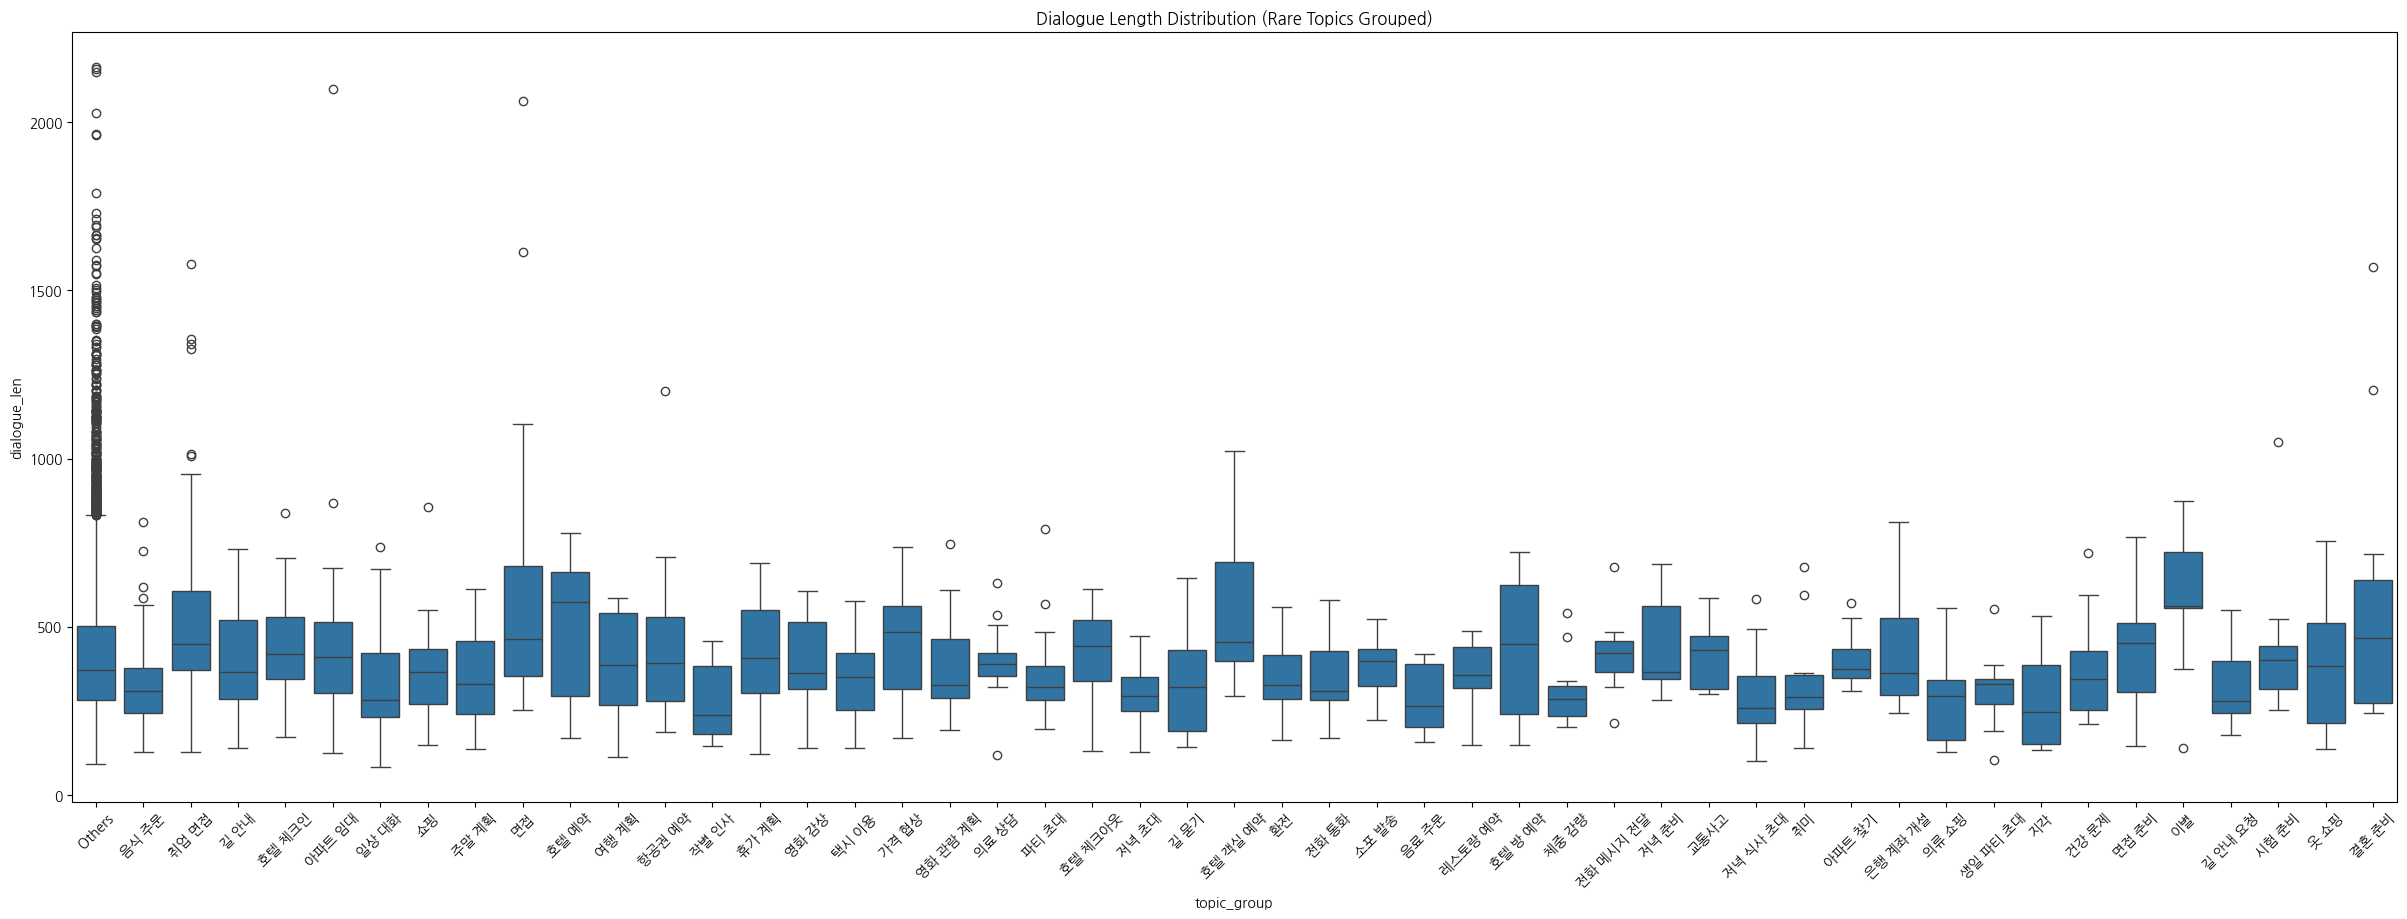

In [50]:
# 대화 길이 분포 topic별 시각화 (Box Plot)
rare_topics = topic_counts[topic_counts <= 10].index # 10건 이하 그룹화

train_df["topic_group"] = train_df["topic"].apply(
    lambda x: "Others" if x in rare_topics else x
)

ordered_topics = train_df["topic_group"].value_counts().index # 빈도수 정렬

plt.figure(figsize=(30, 10))
sns.boxplot(x="topic_group", y="dialogue_len", data=train_df, order=ordered_topics)
plt.xticks(rotation=45)
plt.title("Dialogue Length Distribution (Rare Topics Grouped)")
plt.show()

In [ ]:
# 텍스트 빈도 topic별 word cloud
stop_groups = {
    "speakers": {"Person1", "Person2", "Person3", "사람1", "사람2"},
    "greetings": {"안녕하세요", "안녕", "반갑습니다", "감사합니다", "고맙습니다", "실례합니다", "죄송합니다", "미안해요", "알겠습니다"},
    "fillers": {"음", "아", "오", "에", "어", "글쎄", "막", "막상", "저기요"},
    "demonstratives": {"이", "그", "저", "여기", "거기", "저기", "이거", "그거", "저거", "뭐", "어떤", "다른", "왜"},
    "conjunctions": {"그리고", "하지만", "그런데", "그래서", "그럼", "그래도", "그러면"},
    "particles": {"네", "예", "아니오", "아니요", "어쩌면", "그냥", "좀", "정말", "진짜", "매우", "아주", "너무", "잘", "더", "다", "안", "아직", "가장"},
    "josa": {"가", "의", "은", "는", "을", "를", "이", "도", "로", "으로", "와", "과", "한테", "에", "에서"},
    "bound_nouns": {"수", "것", "거", "적", "분", "데", "번", "쪽", "시", "정도", "두"},
    "ending_forms": {"있어요", "있나요", "있습니다", "해요", "합니다", "할게요", "인가요", "였어요", "네요", "주세요", "거예요", "됩니다", "돼요", "싶습니다"},
    "verb_stems": {"있는", "있어", "있고", "있던", "있게", "있음", "있을", "아닌", "아니", "같아요", "같은", "대해"},
    "personal_prons": {"저는", "제가", "제", "저희", "나", "내가", "우리가", "우리"},
    "time_words": {"오늘", "내일", "어제", "지금", "이제", "요즘"},
    "etc": {"드릴까요", "생각합니다", "많은", "맞아요", "다음", "있다고", "어떻게", "좋아요", "여기서", "있네요" "좋네요", "알고", "좋은"},
}

colormaps = ["viridis", "plasma", "inferno", "magma", "cividis",
             "spring", "summer", "autumn", "winter", "cool",
             "hot", "copper", "Wistia", "Set2", "Paired"]

def wordcloud_by_topic(df, topic_name):
    text = " ".join(df[df["topic"] == topic_name]["dialogue"])

    # 화자 태그 제거
    clean_text = re.sub(r"#Person\d+#:", "", text)

    custom_stopwords = set(STOPWORDS).union(*stop_groups.values())
    # custom_stopwords = set().union(stop_groups["speakers"], stop_groups["fillers"])

    selected_cmap = random.choice(colormaps)
    wordcloud = WordCloud(
        width=1600, height=800,
        background_color="white",
        font_path="NanumGothic",
        stopwords=custom_stopwords,  # 불용어 적용
        regexp=r"[\w\"]+",           # 단어 추출 방식 지정
        colormap=selected_cmap,
    ).generate(clean_text)

    plt.figure(figsize=(16, 8))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.title(f"Word Cloud for Topic: {topic_name}")
    plt.axis("off")
    plt.show()

# top 5 topic
top_topics = train_df["topic"].value_counts().head(5).index
for t in top_topics:
    wordcloud_by_topic(train_df, t)